# Expérience 1 — popularité sur fenêtre glissante

**Question** : sur quelle durée faut-il compter les clics pour recommander « ce
qu'on lit en ce moment » ?

Au moment de cette expérience, le projet utilisait la popularité calculée sur
**tout** l'historique. Sur un flux d'actualité, c'est probablement une erreur : un
article très lu il y a dix jours n'intéresse plus personne. La conclusion de ce
notebook a fait changer ce choix — voir la fin.

Cette méthode ne personnalise rien — elle sert la même liste à tous. Elle est donc
la **référence à battre** : toute méthode plus complexe doit faire mieux.

## Protocole commun

Identique dans tous les notebooks d'expérimentation, sinon les chiffres ne sont pas
comparables :

- **découpage temporel 60 / 20 / 20** sur `click_timestamp` ;
- artefacts construits sur la **seule** période d'entraînement (`models_split/`) ;
- réglage sur la **validation** ; la période de test reste intacte jusqu'à la mesure
  finale (notebook 07) ;
- lecteurs évalués : connus à l'entraînement **et** actifs pendant la période
  d'évaluation ;
- métriques : HitRate@5, Recall@5, couverture, personnalisation.

> Prérequis : `python -m src.evaluate --data-dir data/news-portal-user --out-dir models_split`

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.append('..')

from src import experiments as xp
from src.recommender import Recommender

DATA = Path('..') / 'data' / 'news-portal-user'
MODELS = Path('..') / 'models_split'

train, val, test = xp.load_split(DATA)
reco = Recommender(MODELS)
users, cible = xp.eval_users(reco, val, max_users=2000)
print(f'{len(users):,} lecteurs évalués sur la période de validation')

[clicks] 1 fichier(s) vide(s) ignoré(s) : clicks_hour_100.csv


[split] entraînement 1,792,908 | validation 597,636 | test 597,637
[split] bornes temporelles : t60=1507602953792 t80=1507843212579


2,000 lecteurs évalués sur la période de validation


## Grille de fenêtres

Pour chaque durée, on compte les clics des dernières heures de la période
d'entraînement et on prend les 5 articles les plus lus.

In [2]:
FENETRES = [1, 3, 6, 12, 24, 48, 72, 240]

resultats = {}
tailles = {}
for heures in FENETRES:
    pool = xp.recent_pool(train, heures)
    tailles[heures] = pool.size
    resultats[f'{heures} h'] = xp.make_popularity(pool, reco)

tableau = xp.compare(resultats, users, cible, n_articles=reco.n_articles)
tableau.insert(0, 'articles dans la fenêtre', [tailles[h] for h in FENETRES])
tableau

,articles dans la fenêtre,HitRate@5,Recall@5,couverture %,personnalisation %
configuration,,,,,
1 h,791,0.2190,0.0489,0.004,5.4
3 h,1669,0.2150,0.0464,0.004,5.4
6 h,2657,0.1480,0.0246,0.004,7.7
12 h,5086,0.1190,0.0195,0.004,7.9
24 h,6777,0.1060,0.0160,0.004,8.2
48 h,9133,0.1015,0.0156,0.004,10.6
72 h,11244,0.1010,0.0155,0.005,10.6
240 h,29118,0.0075,0.0006,0.007,18.2


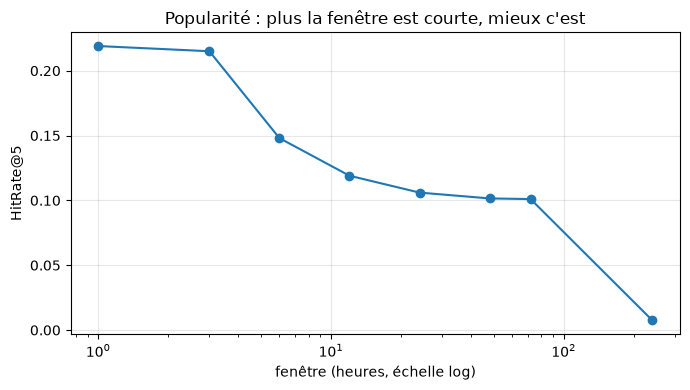

In [3]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(FENETRES, tableau['HitRate@5'].to_numpy(), marker='o')
ax.set_xscale('log')
ax.set_xlabel("fenêtre (heures, échelle log)")
ax.set_ylabel('HitRate@5')
ax.set_title("Popularité : plus la fenêtre est courte, mieux c'est")
ax.grid(alpha=.3)
plt.tight_layout()

## Lecture

Le résultat est le fait le plus important de toute l'évaluation : **la durée de la
fenêtre compte davantage que le choix de l'algorithme**. La même méthode, avec un
comptage sur quelques heures au lieu de tout l'historique, change d'un ordre de
grandeur.

Explication : 48 % des articles lus pendant la période d'évaluation n'avaient
**jamais** été cliqués pendant l'entraînement. Ils viennent d'être publiés. Une
fenêtre courte capte cette vague, une fenêtre longue la noie dans l'historique.

Conséquence pour le produit, désormais implémentée : `prepare_model` produit
`popular_recent.npy` (fenêtre de 1 h, pour le classement) et
`candidates_recent.npy` (vivier de 6 h), et c'est la stratégie servie en
production — 4 places de popularité récente plus 1 de contenu. Ces trois
artefacts de fraîcheur, 23 Ko en tout, arrivent à la Function par *blob input
binding* et sont donc relus à chaque appel : une mise à jour horaire ne demande
aucun redémarrage (voir `docs/architecture.md` § 3.a).

Ce qui reste à construire est le recalcul **continu** de la fenêtre à partir d'un
flux de clics ; aujourd'hui elle est recalculée par le traitement hors-ligne.

La meilleure fenêtre trouvée ici sert de vivier de candidats aux autres notebooks.